# BÀI 2 – PHÂN TÍCH DỮ LIỆU KHẢO SÁT
## Chủ đề: Chất lượng Wifi tại Trường Đại học Công nghiệp TP.HCM (IUH)

**Hai câu hỏi nghiên cứu chính:**
1. Những yếu tố nào ảnh hưởng đến mức độ hài lòng của sinh viên về chất lượng Wifi tại IUH?
2. Sinh viên muốn cải thiện điều gì để nâng cao trải nghiệm sử dụng Wifi tại trường?

---
**Môn:** Khoa học Dữ liệu | **Trường:** IUH | **Năm:** 2026

## 0. Cài đặt thư viện

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Font hỗ trợ tiếng Việt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


---
## 2.1 – Mô tả dữ liệu

In [ ]:
# Đọc dữ liệu (đặt file .xlsx cùng thư mục với notebook này)
df_raw = pd.read_excel('SurveyData_Clean.xlsx', header=2)

# Đổi tên cột cho gọn
df_raw.columns = ['MaPhieu','Khoa_Nganh','NamHoc','GioiTinh','NgayKhaoSat',
                   'Q1_TocDo','Q2_VungPhu','Q3_OnDinh','Q4_SoLuongAP',
                   'Q5_HocOnline','Q6_DangNhap','Q7_TongThe',
                   'Q8_VanDe','Q9_CaiThien','Q10_MucDich']

print(f'Kích thước dataset: {df_raw.shape[0]} phiếu x {df_raw.shape[1]} cột')
print()
df_raw.head(5)

Kích thước dataset: 58 phiếu x 15 cột



,MaPhieu,Khoa_Nganh,NamHoc,GioiTinh,NgayKhaoSat,Q1_TocDo,Q2_VungPhu,Q3_OnDinh,Q4_SoLuongAP,Q5_HocOnline,Q6_DangNhap,Q7_TongThe,Q8_VanDe,Q9_CaiThien,Q10_MucDich
0,1,CONG NGHE THONG TIN,2.0,NAM,19/03/2026,3,4,2.0,4.0,2.0,2.0,3.0,"Các khu vực chậm, dễ mất kết nối",Khu vực thiếu sóng nghiêm trọng: Các phòng học...,Cung cấp thêm nhiều điểm truy cập
1,2,VIEN TAI CHINH KE TOAN,1.0,NU,19/03/2026,2,3,2.0,NaN,2.0,4.0,3.0,Wifi ở thư viện rất tốt nhưng các khu vực khác...,"Không có khu vực nào thừa sóng, Khu vực thiếu ...",Cải thiện tốc độ wifi và các khu vực công cộng...
2,3,LUAT QUOC TE,1.0,KHAC,19/03/2026,1,1,1.0,1.0,1.0,1.0,1.0,Đang sử dụng bị mât,Tầng nào cũng thiếu sóng,"1 tầng của 1 tòa ít nhất 3 cục, pass dễ dàng k..."
3,4,LUAT KINH TE,1.0,NU,19/03/2026,1,3,1.0,1.0,2.0,3.0,1.0,"Tốc độ mạng chậm, hay mất kết nối",Những tầng trên cao hay bị thiếu sóng,"Tặng thêm những điểm phát sóng wifi, pass wifi..."
4,5,CONG NGHE HOA HOC,3.0,NAM,19/03/2026,1,1,1.0,1.0,1.0,1.0,1.0,"Mất kết nối, kết nối được sử dụng cũng không được",Nhiều tầng học không có wifi,Lắp wifi free full trường


In [ ]:
# Kiểu dữ liệu và missing values
info = pd.DataFrame({
    'Kiểu dữ liệu': df_raw.dtypes,
    'Số giá trị null': df_raw.isnull().sum(),
    'Tỉ lệ null (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
})
print('=== Thông tin tổng quan ==='); print(info)

=== Thông tin tổng quan ===
             Kiểu dữ liệu  Số giá trị null  Tỉ lệ null (%)
MaPhieu             int64                0             0.0
Khoa_Nganh         object                0             0.0
NamHoc            float64                4             6.9
GioiTinh           object                4             6.9
NgayKhaoSat        object                5             8.6
Q1_TocDo            int64                0             0.0
Q2_VungPhu          int64                0             0.0
Q3_OnDinh         float64                3             5.2
Q4_SoLuongAP      float64                6            10.3
Q5_HocOnline      float64                4             6.9
Q6_DangNhap       float64                1             1.7
Q7_TongThe        float64                1             1.7
Q8_VanDe           object                5             8.6
Q9_CaiThien        object                7            12.1
Q10_MucDich        object                5             8.6


In [ ]:
# Thống kê mô tả các câu Likert
likert_cols = ['Q1_TocDo','Q2_VungPhu','Q3_OnDinh','Q4_SoLuongAP',
               'Q5_HocOnline','Q6_DangNhap','Q7_TongThe']

likert_labels = {
    'Q1_TocDo'    : 'Q1 - Tốc độ kết nối',
    'Q2_VungPhu'  : 'Q2 - Vùng phủ sóng',
    'Q3_OnDinh'   : 'Q3 - Độ ổn định',
    'Q4_SoLuongAP': 'Q4 - Số lượng Access Point',
    'Q5_HocOnline': 'Q5 - Học online',
    'Q6_DangNhap' : 'Q6 - Quy trình đăng nhập',
    'Q7_TongThe'  : 'Q7 - Hài lòng tổng thể ⭐'
}

desc = df_raw[likert_cols].describe().round(2)
desc.index.name = 'Thống kê'
print('=== Thống kê mô tả (Likert 1–5) ===')
desc

=== Thống kê mô tả (Likert 1–5) ===


,Q1_TocDo,Q2_VungPhu,Q3_OnDinh,Q4_SoLuongAP,Q5_HocOnline,Q6_DangNhap,Q7_TongThe
Thống kê,,,,,,,
count,58.00,58.00,55.00,52.00,54.00,57.00,57.00
mean,2.81,3.09,2.75,2.87,2.87,2.88,3.07
std,1.07,0.88,1.00,1.05,1.06,1.12,1.02
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.00,3.00,2.00,2.00,2.00,2.00,3.00
50%,3.00,3.00,3.00,3.00,3.00,3.00,3.00
75%,3.00,4.00,3.00,4.00,4.00,4.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00


---
## 2.2 – Xử lý dữ liệu (Data Cleaning)

In [ ]:
df = df_raw.copy()

# Chuẩn hóa cột phân loại
df['GioiTinh'] = df['GioiTinh'].str.upper().str.strip()
df['GioiTinh'] = df['GioiTinh'].replace({'NỮ':'NU','NƯ':'NU','KHÁC':'KHAC'})

# Điền null Likert bằng median (missing ít, ảnh hưởng thấp)
for col in likert_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    df[col] = df[col].astype(int)

# Điền null NamHoc bằng mode
df['NamHoc'] = df['NamHoc'].fillna(df['NamHoc'].mode()[0]).astype(int)

# Điền null GioiTinh bằng 'KHONG_RO'
df['GioiTinh'] = df['GioiTinh'].fillna('KHONG_RO')

print(f'Null còn lại sau xử lý (Likert): {df[likert_cols].isnull().sum().sum()}')
print(f'Tổng phiếu hợp lệ: {len(df)}')
print()
print('Phân bố Giới tính:', df['GioiTinh'].value_counts().to_dict())
print('Phân bố Năm học: ', df['NamHoc'].value_counts().sort_index().to_dict())

Null còn lại sau xử lý (Likert): 0
Tổng phiếu hợp lệ: 58

Phân bố Giới tính: {'NAM': 24, 'NU': 21, 'KHAC': 9, 'KHONG_RO': 4}
Phân bố Năm học:  {1: 17, 2: 35, 3: 6}


---
## 2.3 – Thống kê cơ bản

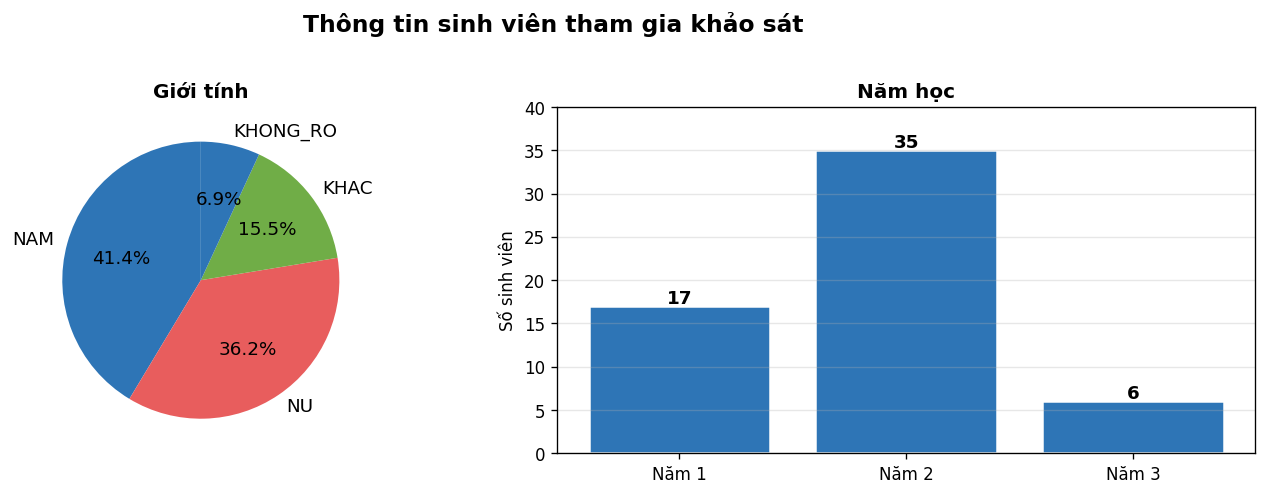

✅ Lưu chart_01_demographics.png


In [ ]:
# ── Biểu đồ 1: Phân bố Giới tính & Năm học ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Thông tin sinh viên tham gia khảo sát', fontsize=14, fontweight='bold', y=1.02)

# Giới tính
gt = df['GioiTinh'].value_counts()
colors_gt = ['#2E75B6','#E85D5D','#70AD47']
axes[0].pie(gt.values, labels=gt.index, autopct='%1.1f%%',
            colors=colors_gt[:len(gt)], startangle=90,
            textprops={'fontsize':11})
axes[0].set_title('Giới tính', fontsize=12, fontweight='bold')

# Năm học
nh = df['NamHoc'].value_counts().sort_index()
bars = axes[1].bar([f'Năm {i}' for i in nh.index], nh.values,
                    color='#2E75B6', edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, nh.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Năm học', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số sinh viên')
axes[1].set_ylim(0, nh.max()+5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_01_demographics.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_01_demographics.png')

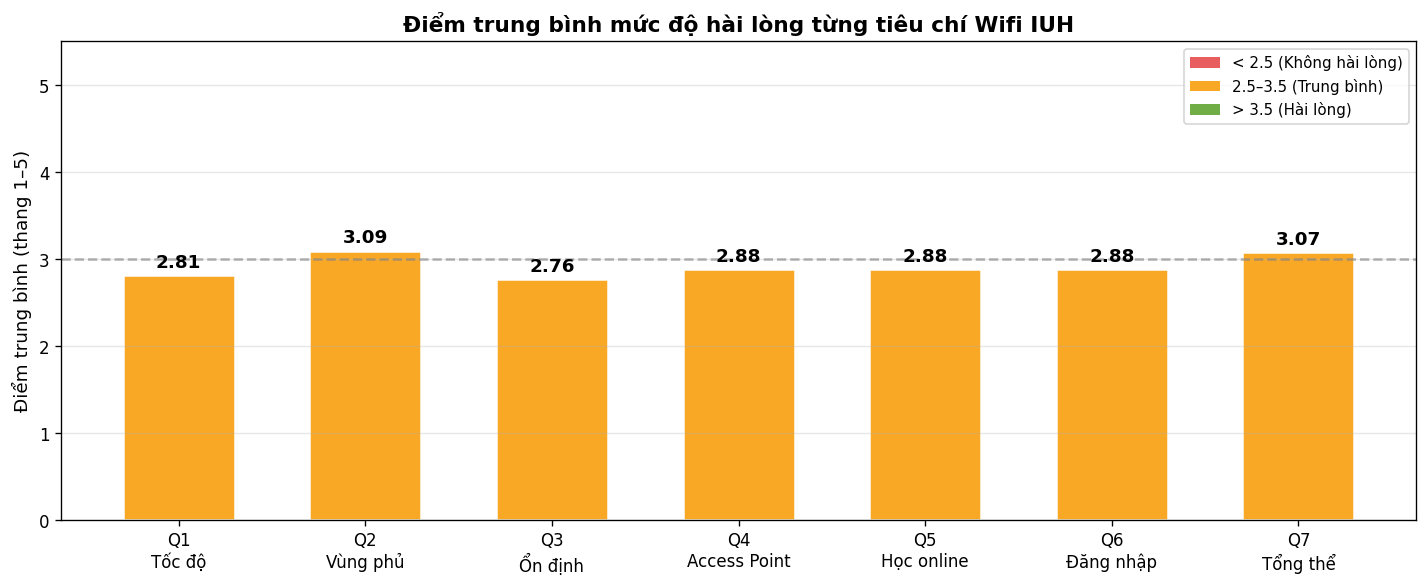

✅ Lưu chart_02_mean_scores.png


In [ ]:
# ── Biểu đồ 2: Điểm trung bình từng câu Likert (Barchart) ───────────────────
means = df[likert_cols].mean().round(2)
labels_short = ['Q1\nTốc độ','Q2\nVùng phủ','Q3\nỔn định',
                'Q4\nAccess Point','Q5\nHọc online','Q6\nĐăng nhập','Q7\nTổng thể']

colors_bar = ['#E85D5D' if v < 2.5 else '#F9A825' if v < 3.5 else '#70AD47'
              for v in means.values]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels_short, means.values, color=colors_bar,
              edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=3, color='gray', linestyle='--', alpha=0.6, label='Mức trung lập (3.0)')
ax.set_ylim(0, 5.5)
ax.set_ylabel('Điểm trung bình (thang 1–5)', fontsize=11)
ax.set_title('Điểm trung bình mức độ hài lòng từng tiêu chí Wifi IUH', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Chú thích màu
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E85D5D', label='< 2.5 (Không hài lòng)'),
                   Patch(facecolor='#F9A825', label='2.5–3.5 (Trung bình)'),
                   Patch(facecolor='#70AD47', label='> 3.5 (Hài lòng)')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart_02_mean_scores.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_02_mean_scores.png')

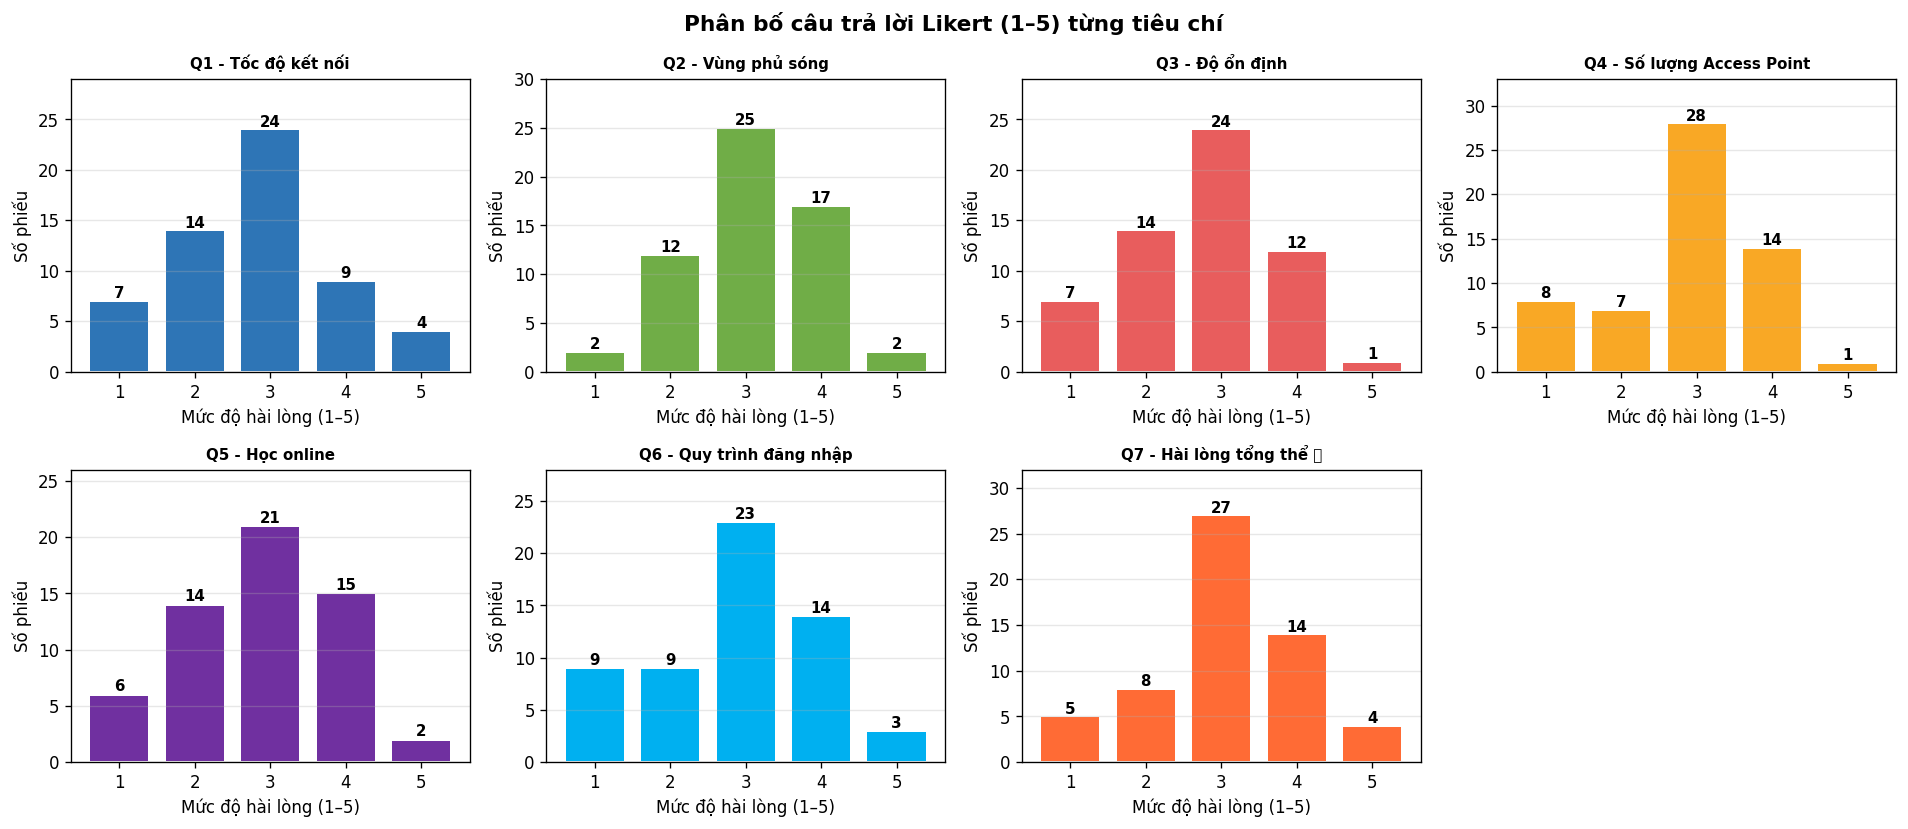

✅ Lưu chart_03_histograms.png


In [ ]:
# ── Biểu đồ 3: Histogram phân bố câu trả lời từng câu Likert ────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Phân bố câu trả lời Likert (1–5) từng tiêu chí', fontsize=13, fontweight='bold')
axes = axes.flatten()

colors_hist = ['#2E75B6','#70AD47','#E85D5D','#F9A825','#7030A0','#00B0F0','#FF6B35']

for i, (col, label) in enumerate(likert_labels.items()):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index, vc.values, color=colors_hist[i], edgecolor='white', linewidth=1.2)
    for x, y in zip(vc.index, vc.values):
        axes[i].text(x, y+0.3, str(y), ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(label, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Mức độ hài lòng (1–5)')
    axes[i].set_ylabel('Số phiếu')
    axes[i].set_xticks([1,2,3,4,5])
    axes[i].set_ylim(0, vc.max()+5)
    axes[i].grid(axis='y', alpha=0.3)

axes[7].axis('off')  # ô trống cuối
plt.tight_layout()
plt.savefig('chart_03_histograms.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_03_histograms.png')

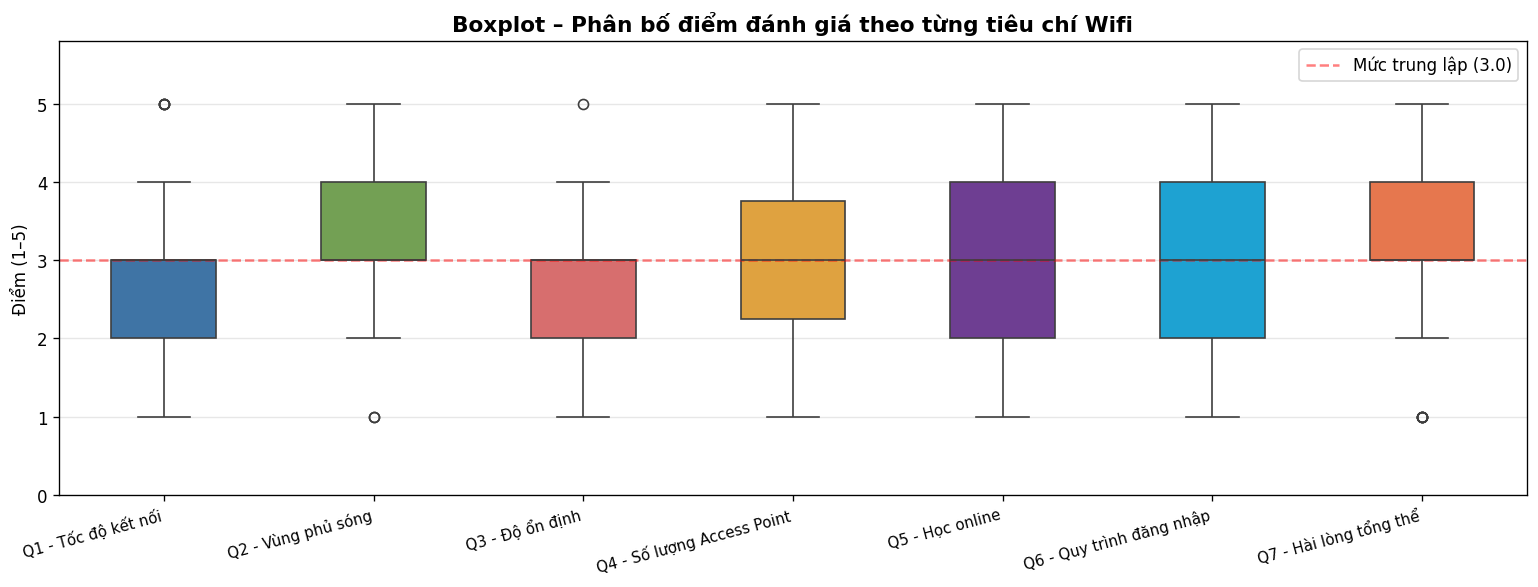

✅ Lưu chart_04_boxplot.png


In [ ]:
# ── Biểu đồ 4: Boxplot so sánh các tiêu chí ─────────────────────────────────
df_melt = df[likert_cols].melt(var_name='Tiêu chí', value_name='Điểm')
df_melt['Tiêu chí'] = df_melt['Tiêu chí'].map({
    col: label.replace(' ⭐','') for col, label in likert_labels.items()
})

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_melt, x='Tiêu chí', y='Điểm',
            palette=colors_hist[:7], ax=ax, width=0.5)
ax.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Mức trung lập (3.0)')
ax.set_title('Boxplot – Phân bố điểm đánh giá theo từng tiêu chí Wifi', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Điểm (1–5)')
ax.set_ylim(0, 5.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart_04_boxplot.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_04_boxplot.png')

---
## 2.4 – Tương quan giữa các câu hỏi (Correlation)

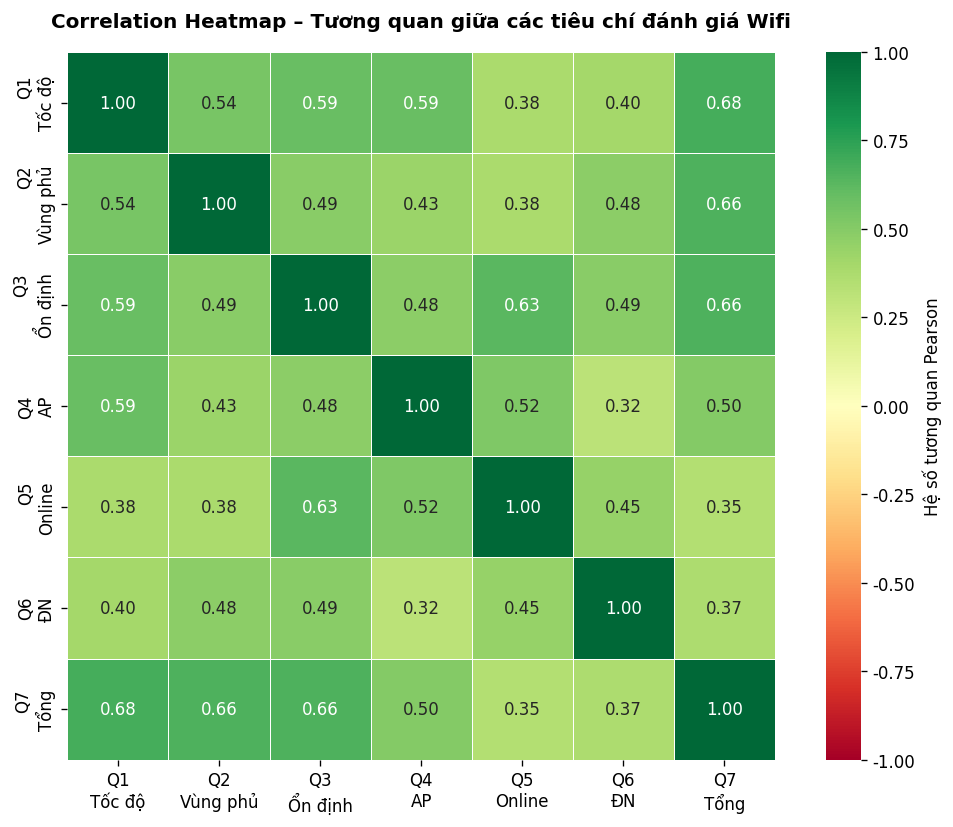

✅ Lưu chart_05_heatmap.png

=== Ma trận tương quan ===
              Q1\nTốc độ  Q2\nVùng phủ  Q3\nỔn định  Q4\nAP  Q5\nOnline  \
Q1\nTốc độ          1.00          0.54         0.59    0.59        0.38   
Q2\nVùng phủ        0.54          1.00         0.49    0.43        0.38   
Q3\nỔn định         0.59          0.49         1.00    0.48        0.63   
Q4\nAP              0.59          0.43         0.48    1.00        0.52   
Q5\nOnline          0.38          0.38         0.63    0.52        1.00   
Q6\nĐN              0.40          0.48         0.49    0.32        0.45   
Q7\nTổng            0.68          0.66         0.66    0.50        0.35   

              Q6\nĐN  Q7\nTổng  
Q1\nTốc độ      0.40      0.68  
Q2\nVùng phủ    0.48      0.66  
Q3\nỔn định     0.49      0.66  
Q4\nAP          0.32      0.50  
Q5\nOnline      0.45      0.35  
Q6\nĐN          1.00      0.37  
Q7\nTổng        0.37      1.00  


In [ ]:
# ── Biểu đồ 5: Correlation Heatmap ───────────────────────────────────────────
corr = df[likert_cols].corr().round(2)

# Đổi tên cho dễ đọc trên heatmap
short_names = ['Q1\nTốc độ','Q2\nVùng phủ','Q3\nỔn định',
               'Q4\nAP','Q5\nOnline','Q6\nĐN','Q7\nTổng']
corr.index = short_names
corr.columns = short_names

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # chỉ hiện tam giác dưới
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Hệ số tương quan Pearson'},
            ax=ax)
ax.set_title('Correlation Heatmap – Tương quan giữa các tiêu chí đánh giá Wifi',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart_05_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_05_heatmap.png')
print()
print('=== Ma trận tương quan ===')
print(corr)

In [ ]:
# Nhận xét tương quan mạnh nhất với Q7_TongThe
corr_full = df[likert_cols].corr()
corr_q7 = corr_full['Q7_TongThe'].drop('Q7_TongThe').sort_values(ascending=False)
print('=== Tương quan với Q7_TongThe (Hài lòng tổng thể) ===')
for col, val in corr_q7.items():
    label = likert_labels[col]
    level = '🔴 Mạnh' if abs(val) >= 0.6 else '🟡 Trung bình' if abs(val) >= 0.4 else '⚪ Yếu'
    print(f'  {label:<35} r = {val:.3f}  {level}')

=== Tương quan với Q7_TongThe (Hài lòng tổng thể) ===
  Q1 - Tốc độ kết nối                 r = 0.682  🔴 Mạnh
  Q2 - Vùng phủ sóng                  r = 0.664  🔴 Mạnh
  Q3 - Độ ổn định                     r = 0.658  🔴 Mạnh
  Q4 - Số lượng Access Point          r = 0.500  🟡 Trung bình
  Q6 - Quy trình đăng nhập            r = 0.369  ⚪ Yếu
  Q5 - Học online                     r = 0.348  ⚪ Yếu


---
## 2.5 – Xác định yếu tố quan trọng (Feature Importance)

In [ ]:
# ── RandomForest → Feature Importance ───────────────────────────────────────
feature_cols = ['Q1_TocDo','Q2_VungPhu','Q3_OnDinh','Q4_SoLuongAP','Q5_HocOnline','Q6_DangNhap']
target_col   = 'Q7_TongThe'

X = df[feature_cols]
y = df[target_col]

# Train/Test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'=== Đánh giá mô hình RandomForest ===')
print(f'  Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'  R² Score  : {r2:.4f}')
print(f'  MSE       : {mse:.4f}')
print(f'  RMSE      : {np.sqrt(mse):.4f}')

=== Đánh giá mô hình RandomForest ===
  Train size: 46 | Test size: 12
  R² Score  : 0.1946
  MSE       : 1.4933
  RMSE      : 1.2220


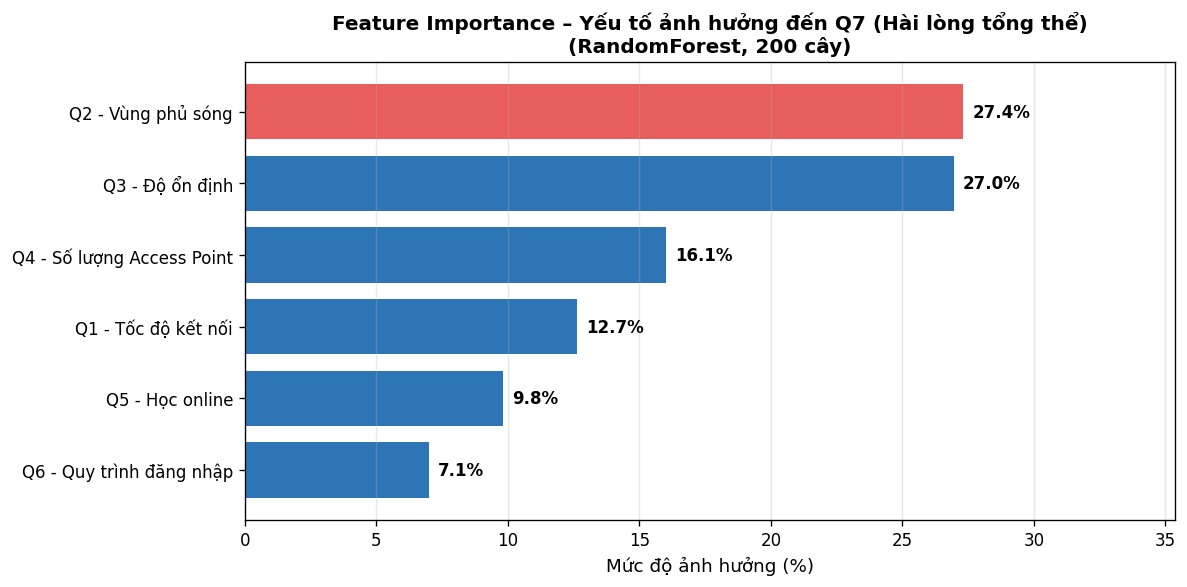

✅ Lưu chart_06_feature_importance.png


In [ ]:
# ── Biểu đồ 6: Feature Importance ────────────────────────────────────────────
importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True)

feat_labels = {
    'Q1_TocDo'    : 'Q1 - Tốc độ kết nối',
    'Q2_VungPhu'  : 'Q2 - Vùng phủ sóng',
    'Q3_OnDinh'   : 'Q3 - Độ ổn định',
    'Q4_SoLuongAP': 'Q4 - Số lượng Access Point',
    'Q5_HocOnline': 'Q5 - Học online',
    'Q6_DangNhap' : 'Q6 - Quy trình đăng nhập'
}
importance.index = [feat_labels[c] for c in importance.index]

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = ['#E85D5D' if v == importance.max() else '#2E75B6'
              for v in importance.values]
bars = ax.barh(importance.index, importance.values * 100,
               color=colors_imp, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, importance.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mức độ ảnh hưởng (%)', fontsize=11)
ax.set_title('Feature Importance – Yếu tố ảnh hưởng đến Q7 (Hài lòng tổng thể)\n(RandomForest, 200 cây)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, importance.max()*100 + 8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_06_feature_importance.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_06_feature_importance.png')

---
## 2.6 – Phân tích theo nhóm sinh viên

Q7 trung bình theo Năm học:
        Điểm TB  Số phiếu
NamHoc                   
1          2.94        17
2          3.06        35
3          3.50         6


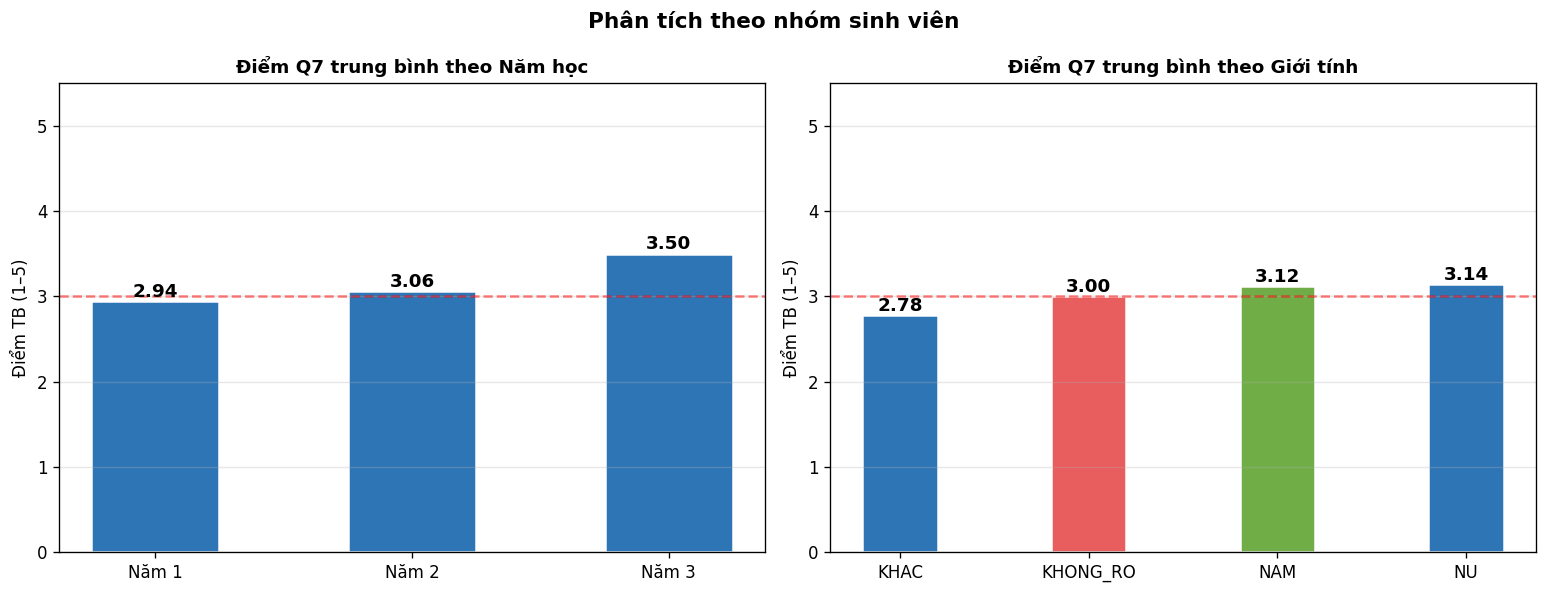

✅ Lưu chart_07_group_analysis.png


In [ ]:
# ── Biểu đồ 7: Q7 trung bình theo Năm học ────────────────────────────────────
q7_by_year = df.groupby('NamHoc')['Q7_TongThe'].agg(['mean','count']).round(2)
q7_by_year.columns = ['Điểm TB','Số phiếu']
print('Q7 trung bình theo Năm học:')
print(q7_by_year)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phân tích theo nhóm sinh viên', fontsize=13, fontweight='bold')

# Q7 theo năm học
years = q7_by_year.index.astype(str)
bars1 = axes[0].bar([f'Năm {y}' for y in years], q7_by_year['Điểm TB'],
                     color='#2E75B6', edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars1, q7_by_year['Điểm TB']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=3, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Điểm Q7 trung bình theo Năm học', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Điểm TB (1–5)')
axes[0].set_ylim(0, 5.5)
axes[0].grid(axis='y', alpha=0.3)

# Q7 theo giới tính
q7_gt = df.groupby('GioiTinh')['Q7_TongThe'].mean().round(2).sort_values()
colors_gt2 = ['#2E75B6','#E85D5D','#70AD47']
bars2 = axes[1].bar(q7_gt.index, q7_gt.values,
                     color=colors_gt2[:len(q7_gt)], edgecolor='white', linewidth=1.5, width=0.4)
for bar, val in zip(bars2, q7_gt.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(y=3, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Điểm Q7 trung bình theo Giới tính', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Điểm TB (1–5)')
axes[1].set_ylim(0, 5.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_07_group_analysis.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_07_group_analysis.png')

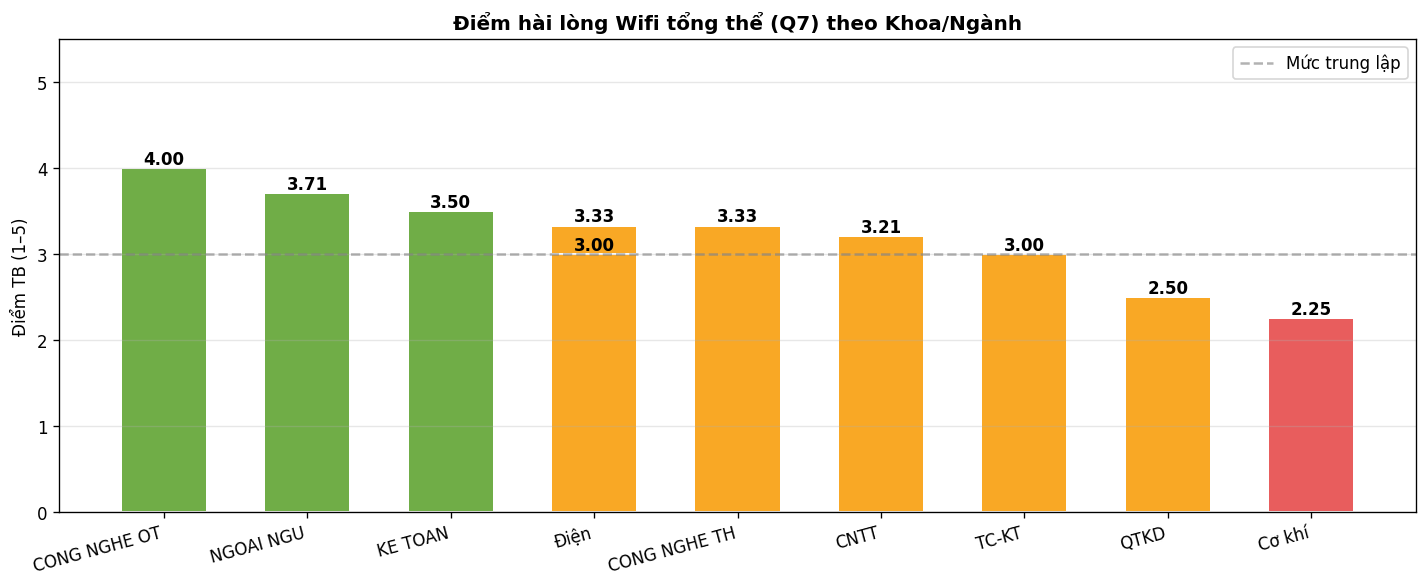

✅ Lưu chart_08_by_khoa.png


In [ ]:
# ── Biểu đồ 8: Phân bố Q7 theo Khoa (top khoa có đủ mẫu) ────────────────────
khoa_count = df['Khoa_Nganh'].value_counts()
khoa_valid = khoa_count[khoa_count >= 2].index  # chỉ lấy khoa có >= 2 phiếu
df_khoa = df[df['Khoa_Nganh'].isin(khoa_valid)]

q7_khoa = df_khoa.groupby('Khoa_Nganh')['Q7_TongThe'].mean().sort_values(ascending=False).round(2)

# Rút gọn tên khoa cho đẹp
def shorten_khoa(name):
    mapping = {
        'CONG NGHE THONG TIN':'CNTT',
        'VIEN TAI CHINH KE TOAN':'TC-KT',
        'LUAT QUOC TE':'Luật QT',
        'LUAT KINH TE':'Luật KT',
        'CO KHI':'Cơ khí',
        'DIEN':'Điện',
        'QUAN TRI KINH DOANH':'QTKD',
    }
    for k, v in mapping.items():
        if k in str(name).upper():
            return v
    return str(name)[:12]

q7_khoa.index = [shorten_khoa(k) for k in q7_khoa.index]

fig, ax = plt.subplots(figsize=(12, 5))
colors_khoa = ['#E85D5D' if v < 2.5 else '#F9A825' if v < 3.5 else '#70AD47'
               for v in q7_khoa.values]
bars = ax.bar(q7_khoa.index, q7_khoa.values,
              color=colors_khoa, edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars, q7_khoa.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.6, label='Mức trung lập')
ax.set_title('Điểm hài lòng Wifi tổng thể (Q7) theo Khoa/Ngành', fontsize=12, fontweight='bold')
ax.set_ylabel('Điểm TB (1–5)')
ax.set_ylim(0, 5.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('chart_08_by_khoa.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_08_by_khoa.png')

---
## 2.7 – Phân tích câu hỏi mở (Q8, Q9, Q10)

In [ ]:
from collections import Counter
import re

# Stopwords tiếng Việt cơ bản
stopwords_vi = {'và','của','các','là','có','được','trong','cho','với',
                'không','tại','khu','vực','trường','sinh','viên','wifi',
                'thêm','bị','nhà','cần','đang','rất','hơn','nhiều','kết',
                'nối','bạn','tôi','này','đó','một','những','khi','nào',
                'để','như','nên','lên','về','cũng','thì','mà','hay','lại',
                'sử','dụng','vì','do','từ','sau','trên','dưới','theo'}

def word_freq(series, top_n=10):
    words = []
    for text in series.dropna():
        tokens = re.findall(r'[a-zA-Zàáâãèéêìíòóôõùúýăđơưạặắằặẹẽếềệỉịọỏốồổộớờởụủứừựỳỹ]+', str(text).lower())
        words += [w for w in tokens if w not in stopwords_vi and len(w) > 2]
    return Counter(words).most_common(top_n)

freq_q8  = word_freq(df['Q8_VanDe'])
freq_q9  = word_freq(df['Q9_CaiThien'])
freq_q10 = word_freq(df['Q10_MucDich'])

print('Top từ Q8 (Vấn đề):', freq_q8)
print('Top từ Q9 (Cải thiện):', freq_q9)
print('Top từ Q10 (Mục đích):', freq_q10)

Top từ Q8 (Vấn đề): [('sóng', 9), ('yếu', 6), ('thường', 6), ('mạng', 5), ('phủ', 5), ('nhưng', 4), ('kiến', 4), ('định', 3), ('ngồi', 3), ('khá', 3)]
Top từ Q9 (Cải thiện): [('sóng', 27), ('thiếu', 19), ('học', 15), ('thừa', 8), ('phòng', 7), ('thư', 7), ('yếu', 7), ('lớp', 7), ('viện', 6), ('tòa', 6)]
Top từ Q10 (Mục đích): [('học', 8), ('kiến', 8), ('thay', 7), ('đổi', 7), ('sóng', 6), ('lớp', 6), ('lắp', 5), ('phủ', 5), ('thiện', 4), ('tốc', 4)]


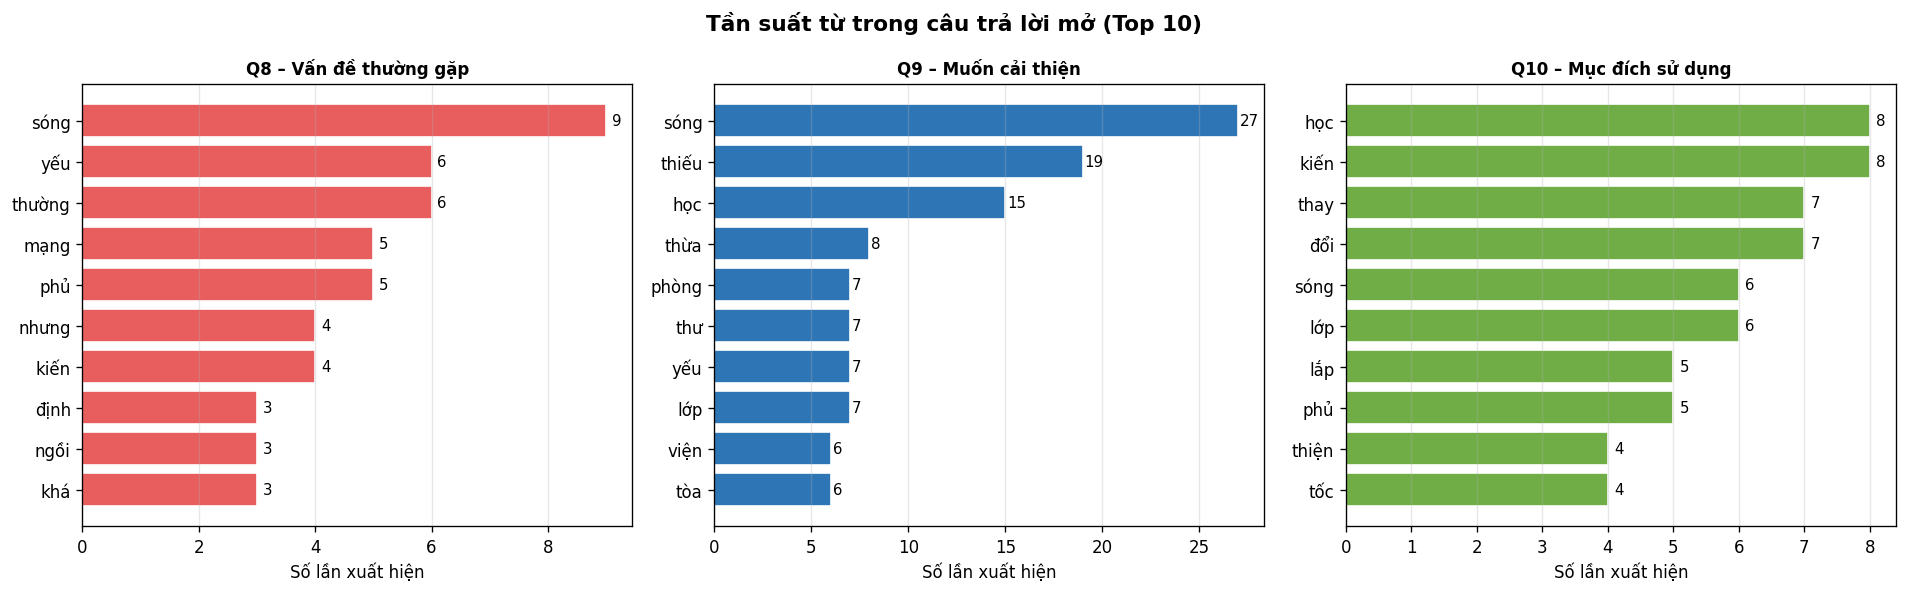

✅ Lưu chart_09_word_freq.png


In [ ]:
# ── Biểu đồ 9: Word Frequency Q8, Q9, Q10 ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tần suất từ trong câu trả lời mở (Top 10)', fontsize=13, fontweight='bold')

for ax, freq, title, color in [
    (axes[0], freq_q8,  'Q8 – Vấn đề thường gặp', '#E85D5D'),
    (axes[1], freq_q9,  'Q9 – Muốn cải thiện',    '#2E75B6'),
    (axes[2], freq_q10, 'Q10 – Mục đích sử dụng', '#70AD47'),
]:
    if not freq:
        ax.text(0.5, 0.5, 'Không đủ dữ liệu', ha='center', transform=ax.transAxes)
        continue
    words, counts = zip(*freq)
    bars = ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Số lần xuất hiện')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_09_word_freq.png', bbox_inches='tight')
plt.show()
print('✅ Lưu chart_09_word_freq.png')

---
## 2.8 – Tóm tắt kết quả & Thảo luận

In [ ]:
print('=' * 60)
print('  TÓM TẮT KẾT QUẢ PHÂN TÍCH BÀI 2')
print('=' * 60)
print(f'\n📋 Tổng số phiếu khảo sát: {len(df)}')
print()

print('📊 Điểm trung bình từng tiêu chí:')
means_full = df[likert_cols].mean()
for col, mean in means_full.items():
    label = likert_labels[col]
    icon = '🔴' if mean < 2.5 else '🟡' if mean < 3.5 else '🟢'
    print(f'  {icon} {label:<40} {mean:.2f}/5')

print()
print('🔍 Yếu tố ảnh hưởng MẠNH nhất đến hài lòng tổng thể (Q7):')
imp_full = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
for i, (col, val) in enumerate(imp_full.items(), 1):
    print(f'  {i}. {feat_labels[col]:<35} {val*100:.1f}%')

print()
print('💡 Kết luận:')
top1 = imp_full.index[0]
top2 = imp_full.index[1]
print(f'  → {feat_labels[top1]} và {feat_labels[top2]}')
print(f'     là 2 yếu tố ảnh hưởng lớn nhất đến mức hài lòng Wifi tổng thể.')
print(f'  → Điểm trung bình tổng thể (Q7): {means_full["Q7_TongThe"]:.2f}/5')
if means_full['Q7_TongThe'] < 3:
    print('  → Đánh giá chung: Sinh viên CHƯA HÀI LÒNG với chất lượng Wifi tại IUH.')
elif means_full['Q7_TongThe'] < 4:
    print('  → Đánh giá chung: Sinh viên HÀI LÒNG Ở MỨC TRUNG BÌNH với Wifi tại IUH.')
else:
    print('  → Đánh giá chung: Sinh viên HÀI LÒNG với chất lượng Wifi tại IUH.')

print()
print('📁 Các biểu đồ đã xuất:')
charts = [
    'chart_01_demographics.png     – Thông tin sinh viên',
    'chart_02_mean_scores.png      – Điểm TB từng tiêu chí',
    'chart_03_histograms.png       – Histogram phân bố',
    'chart_04_boxplot.png          – Boxplot so sánh',
    'chart_05_heatmap.png          – Correlation Heatmap',
    'chart_06_feature_importance.png – Feature Importance',
    'chart_07_group_analysis.png   – Theo năm học & giới tính',
    'chart_08_by_khoa.png          – Theo khoa/ngành',
    'chart_09_word_freq.png        – Word frequency Q8/Q9/Q10',
]
for c in charts:
    print(f'  ✅ {c}')
print()
print('=' * 60)

  TÓM TẮT KẾT QUẢ PHÂN TÍCH BÀI 2

📋 Tổng số phiếu khảo sát: 58

📊 Điểm trung bình từng tiêu chí:
  🟡 Q1 - Tốc độ kết nối                      2.81/5
  🟡 Q2 - Vùng phủ sóng                       3.09/5
  🟡 Q3 - Độ ổn định                          2.76/5
  🟡 Q4 - Số lượng Access Point               2.88/5
  🟡 Q5 - Học online                          2.88/5
  🟡 Q6 - Quy trình đăng nhập                 2.88/5
  🟡 Q7 - Hài lòng tổng thể ⭐                 3.07/5

🔍 Yếu tố ảnh hưởng MẠNH nhất đến hài lòng tổng thể (Q7):
  1. Q2 - Vùng phủ sóng                  27.4%
  2. Q3 - Độ ổn định                     27.0%
  3. Q4 - Số lượng Access Point          16.1%
  4. Q1 - Tốc độ kết nối                 12.7%
  5. Q5 - Học online                     9.8%
  6. Q6 - Quy trình đăng nhập            7.1%

💡 Kết luận:
  → Q2 - Vùng phủ sóng và Q3 - Độ ổn định
     là 2 yếu tố ảnh hưởng lớn nhất đến mức hài lòng Wifi tổng thể.
  → Điểm trung bình tổng thể (Q7): 3.07/5
  → Đánh giá chung: Sinh viên HÀI L